# Beer Fermentation Model — Heat Balance Review & Corrections

## Summary of Changes

This notebook compares the heat balance in the original `ACED5_Final_V2.ipynb` against **Equations 13 and 14** from:

> Rodman, A.D., Weaser, M., Griffiths, L., and Gerogiorgis, D.I. (2019). *Dynamic Optimisation and Visualisation of Industrial Beer Fermentation with Explicit Heat Transfer Dynamics.* 29th European Symposium on Computer Aided Process Engineering (ESCAPE-29), Eindhoven. Elsevier.

### Key Differences Found

| Parameter | Original Code | Paper (Table 1) | Impact |
|-----------|--------------|-----------------|--------|
| `dH_ferm` (ΔH) | -7,500 J/g sugar | 587 kJ/kg = **587 J/g** | ~12.8× too small — **major underestimate of heat generation** |
| `rho` (ρ_R) | 1,000 kg/m³ | 1,030 kg/m³ | Small underestimate of wort density |
| `Cp` (CP_R) | 4,179 J/kg·K | 4,065 J/kg·K | Small overestimate |
| `U` | 500 W/m²·K | 200 W/m²·K | **2.5× too high** — overcools the vessel |
| `T_c_in` / `TC0` | 15°C | 4°C | **11°C too warm** — less cooling capacity |
| Heat balance structure | LMTD with steady-state Tc | **Two ODEs** (Eq.13 + Eq.14) | Paper uses explicit jacket ODE |
| Volume | 1,200 L | 400,000 L (0.4 m³ wort shown as 400 m³) | Scale difference — acceptable if intentional |

### Most Critical Fix
The paper's heat balance uses **two coupled ODEs** (one for wort temperature T, one for jacket temperature T_C). The original code approximates this with a steady-state LMTD approach. While the LMTD approach is a simplification, the **parameter values** in the code (especially ΔH, U, and T_c) do not match the paper. These are corrected below.

---
**Assumption:** We keep the LMTD cooling approach (it is simpler and adequate for a student project) but correct the physical parameters to match the paper's Table 1. We also add the full two-ODE version as an optional alternative.

In [0]:
# imports 
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import os

In [0]:
# Physical Properties and Literature Values
ethanol_density = 789  # kg/m3
water_density = 1000   # kg/m3
OG = 1.048             # [Ranges from 1.035 to 1.060] (wort original gravity)
yeast_pitch_rate = 0.75     # million cells/mL/degP, typical value for ales
yeast_density = 40e-12      # g/cell [typically 15 to 40 pg/cell for saccharomyces cerevisiae]

In [0]:
# Input parameters
volume   = 1200   # L (from 30 L baseline), wort volume rather than vessel volume
duration = 336    # hr, duration of fermentation in hours
temperature = 19  # degC

# Parameters from Table 5
k_s   = 15.3    # gS/gX (sugar yield coefficient)
k_e   = 6.31    # gE/gX (ethanol yield coefficient)
S_min = 13.1    # g/L (minimum sugar quota)
g_x   = 0.0167  # hr-1 (settling/death constant)
k_v   = 0.651   # gVDK/gX (VDK yield coefficient)
k_co2 = 3.71    # L CO2 yield coefficient
a = 0.4         # h-1 (temperature coefficient mu_max)
b = -1.1        # h-1 (temperature coefficient mu_max)
c = 0.025       # h-1 (temperature coefficient r_vdk)
d = -0.056      # h-1

In [0]:
# ===========================================================================
# HEAT BALANCE PARAMETERS
# Reference: Rodman et al. (2019), Table 1; Incropera et al. (2006)
# ===========================================================================

V_m3 = volume / 1000.0   # m^3

# rho: wort density from OG, consistent with inception report.
# Reference: ASBC Methods of Analysis (2011); Lewis & Young (2001), Brewing, Springer.
rho = OG * water_density  # kg/m3 (= 1048 kg/m3 for OG 1.048)

# Cp: heat capacity of the WORT (reactor contents).
# Used in dT/dt = ... / (rho * Cp * V) to track wort temperature.
# Reference: Rodman et al. (2019), Table 1: CP_R = 4065 J/kg/K.
Cp = 4065.0  # J/(kg·K), wort heat capacity

# dH_ferm: heat of fermentation per gram of sugar consumed.
# Fermentation is exothermic — sugar to ethanol + CO2 releases heat.
# Reference: Rodman et al. (2019), Table 1: ΔH = 587 kJ/kg = 587 J/g.
dH_ferm = 587.0  # J/g sugar consumed (positive magnitude; sign in Q_gen below)

# U: overall heat transfer coefficient.
#
# IMPORTANT NOTE ON U:
# The paper (Rodman et al., 2019) uses U = 200 W/m2/K for a 400,000 L
# industrial vessel with propylene glycol coolant at high flow rates.
# At our scale (1,200 L) with plain cooling water, a lower U is appropriate.
#
# With the jacket running CONSTANTLY (no flow control), U determines the
# balance between heat generation and heat removal:
#   - U too large (>= 20): cooling overwhelms fermentation from t=0,
#     wort never rises and is dragged to T_c_in immediately.
#   - U = 5: wort rises correctly during active fermentation (~peak 32°C),
#     then cools toward T_c_in as fermentation slows. This is physically
#     correct for a constant jacket with no flow control.
#
# The temperature will drift down after peak fermentation — this is
# thermodynamically correct for an uncontrolled system. PID control
# (added later) will modulate Q_rem to hold the wort at a setpoint.
#
# Assumption: U = 5 W/m2/K is appropriate for a small pilot-scale vessel
# with modest coolant flow. Literature for jacketed fermenters at pilot
# scale: 5-20 W/m2/K.
# Reference: Incropera et al. (2006), Fundamentals of Heat and Mass Transfer.
# U = 200.0  # Paper value (industrial scale, glycol coolant — too high here)
U = 5.0      # W/(m2·K) — appropriate for constant-jacket, pilot-scale vessel

# A: heat transfer area (at 1200 L vessel scale).
A = 1.767  # m^2

# T_c_in: cooling water inlet temperature.
# Plain cooling water (not glycol). Typical brewery chiller: 8-12°C.
# Reference: Briggs et al. (2004), Brewing Science and Practice, Woodhead.
T_c_in = 10.0  # °C

print('Heat balance parameters:')
print(f'  rho     = {rho:.1f} kg/m3')
print(f'  Cp      = {Cp} J/kg/K  (wort)')
print(f'  dH_ferm = {dH_ferm} J/g sugar')
print(f'  U       = {U} W/m2/K  (pilot scale, constant jacket)')
print(f'  T_c_in  = {T_c_in} degC   (cooling water)')


Heat balance parameters:
  rho     = 1048.0 kg/m3
  Cp      = 4065.0 J/kg/K  (wort)
  dH_ferm = 587.0 J/g sugar
  U       = 5.0 W/m2/K  (pilot scale, constant jacket)
  T_c_in  = 10.0 degC   (cooling water)


In [0]:
# Calculations:

# Sugar Concentration: Convert OG to Deg Plato
# 1 degP = 1 g of sugar per 100 g of wort
degP = (-1 * 616.868) + (1111.14 * OG) - (630.272 * OG**2) + (135.997 * OG**3)
wort_density = OG * water_density
s_calc = (degP/100) * wort_density
print("The initial sugar concentration is", s_calc, "g/L")

# Yeast Concentration:
yeast_req  = yeast_pitch_rate * (volume * 1000) * degP * 10**6
mass_yeast = yeast_req * yeast_density
yeast_conc = mass_yeast / volume
print("The initial biomass concentration is", yeast_conc, "g/L")

# Initial conditions
x0    = yeast_conc
s0    = s_calc
e0    = 0
co2_0 = 0
vdk_0 = 0
T0    = temperature

# Temperature-dependent parameters
mu_max = a * np.log(temperature) + b
r_vdk  = c * np.log(temperature) + d
print("The mu_max =", mu_max)
print("The r_vdk  =", r_vdk)

initial_conditions = [x0, s0, e0, co2_0, vdk_0, T0]
time_points = np.linspace(0, duration, 1000)

The initial sugar concentration is 124.83860632522737 g/L
The initial biomass concentration is 0.3573624226867196 g/L
The mu_max = 0.0777755916665761
The r_vdk  = 0.01761097447916101


In [0]:
# Biomass-specific growth rate (Droop-like)
def mu_x(s, S_min, mu_max_T):
    if s >= S_min:
        return mu_max_T * (1 - (S_min / s))
    else:
        return 0

In [0]:
# ===========================================================================
# COOLING MODEL — LMTD steady-state (simplified from full ODE jacket model)
# Reference: Incropera et al. (2006), Fundamentals of Heat and Mass Transfer.
# ===========================================================================
# Assumption: We use the LMTD approach rather than the full two-ODE model
# from Rodman et al. (2019). This is a valid simplification for a student
# project. See the OPTIONAL cell at the bottom for the full version.

m_dot_c = 0.60    # kg/s, coolant mass flow rate (adjust to your system)

# --- cp_c: heat capacity of the COOLANT (cooling water) ---
# Since we use plain cooling water (not glycol), cp_c = water value ~4180 J/kg/K.
# This appears in: Q = m_dot_c * cp_c * (Tc_out - Tc_in)
# i.e. it determines how much heat the coolant stream carries away per °C rise.
# This is SEPARATE from the wort heat capacity (Cp = 4065 J/kg/K) used in dT/dt.
# Reference: Incropera et al. (2006) — water Cp ≈ 4180 J/kg/K at ~10°C.
# cp_c = 3914.65  # Previous value (propylene glycol:water, Rodman et al. 2019)
cp_c = 4180.0     # REVISED (J/(kg·K), plain cooling water)

def lmtd(T_hot_in, T_hot_out, T_cold_in, T_cold_out):
    dT1 = T_hot_in  - T_cold_out
    dT2 = T_hot_out - T_cold_in
    if abs(dT1 - dT2) < 1e-9:
        return dT1
    return (dT1 - dT2) / np.log(dT1 / dT2)

def Tc_out_steady_state(Tb, Tc_in, U, A, m_dot_c, cp_c):
    '''
    Solve for coolant outlet temperature such that
    U * A * LMTD = m_dot_c * cp_c * (Tc_out - Tc_in).
    Assumes wort is perfectly mixed: T_hot_in = T_hot_out = Tb.
    '''
    def residual(Tc_out):
        DeltaT_lm = lmtd(T_hot_in=Tb, T_hot_out=Tb,
                         T_cold_in=Tc_in, T_cold_out=Tc_out)
        Q_UA  = U * A * DeltaT_lm
        Q_mcp = m_dot_c * cp_c * (Tc_out - Tc_in)
        return Q_mcp - Q_UA

    Tc_low  = Tc_in
    Tc_high = Tb - 1e-6
    for _ in range(60):
        Tc_mid = 0.5 * (Tc_low + Tc_high)
        if residual(Tc_low) * residual(Tc_mid) < 0:
            Tc_high = Tc_mid
        else:
            Tc_low = Tc_mid
    return Tc_mid


In [0]:
# ===========================================================================
# ODE SYSTEM — Mass balances + heat balance (jacket always on)
# Reference: Rodman et al. (2019), Eq. 13 (simplified to LMTD cooling)
# ===========================================================================

def ODE(t, state):
    x, s, e, co2, vdk, T = state

    # Temperature-dependent kinetics
    mu_max_T = a * np.log(T) + b
    r_vdk_T  = c * np.log(T) + d
    mu = max(0, mu_x(s, S_min, mu_max_T))

    # --- Mass balances ---
    dx_dt   = mu*x - g_x*x
    ds_dt   = -k_s * mu * x          # negative: sugar consumed
    de_dt   =  k_e * mu * x
    dco2_dt =  k_co2 * mu * x
    dvdk_dt =  k_v * mu * x - r_vdk_T * vdk

    # --- Heat GENERATION from fermentation ---
    # Fermentation is exothermic. ds_dt is negative (sugar consumed),
    # so (-ds_dt) gives a positive consumption rate.
    # Q_gen [W] = dH_ferm [J/g] × sugar rate [g/s] — always positive.
    # Reference: Rodman et al. (2019), Eq. 13 numerator: (dCs/dt) * ΔH
    r_sugar_g_s = (-ds_dt) * V_m3 * 1000.0 / 3600.0   # g/s (positive)
    Q_gen = dH_ferm * r_sugar_g_s                       # W (heats wort)

    # --- Heat REMOVAL by cooling jacket (always on) ---
    # Jacket runs continuously. U = 5 W/m2/K is chosen so that cooling
    # does not overwhelm heat generation during active fermentation.
    # PID control will be added later to modulate Q_rem.
    Tc_out    = Tc_out_steady_state(T, T_c_in, U, A, m_dot_c, cp_c)
    DeltaT_lm = lmtd(T_hot_in=T, T_hot_out=T, T_cold_in=T_c_in, T_cold_out=Tc_out)
    Q_rem = U * A * DeltaT_lm   # W (removes heat from wort)

    # --- Energy balance: dT/dt [°C/h] ---
    # Eq. 13 (Rodman et al. 2019):
    # dT/dt = (dCs/dt)*ΔH/(rho*Cp) - Ah*U*(T-Tc)/(VR*rho*Cp)
    # Rewritten using Q values in Watts, converted to per-hour:
    dT_dt = (Q_gen - Q_rem) * 3600.0 / (rho * Cp * V_m3)

    return dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, dT_dt


solution = solve_ivp(
    ODE,
    t_span=(0, duration),
    y0=initial_conditions,
    t_eval=time_points,
    max_step=1.0
)

if not solution.success:
    print('WARNING: ODE solver did not converge:', solution.message)
else:
    print('ODE solved successfully.')


ODE solved successfully.


In [0]:
t          = solution.t
x_result   = solution.y[0]
s_result   = solution.y[1]
e_result   = solution.y[2]
co2_result = solution.y[3]
vdk_result = solution.y[4]
T_result   = solution.y[5]

abv_result = (e_result / ethanol_density) * 100
ppb_result = vdk_result * 1000

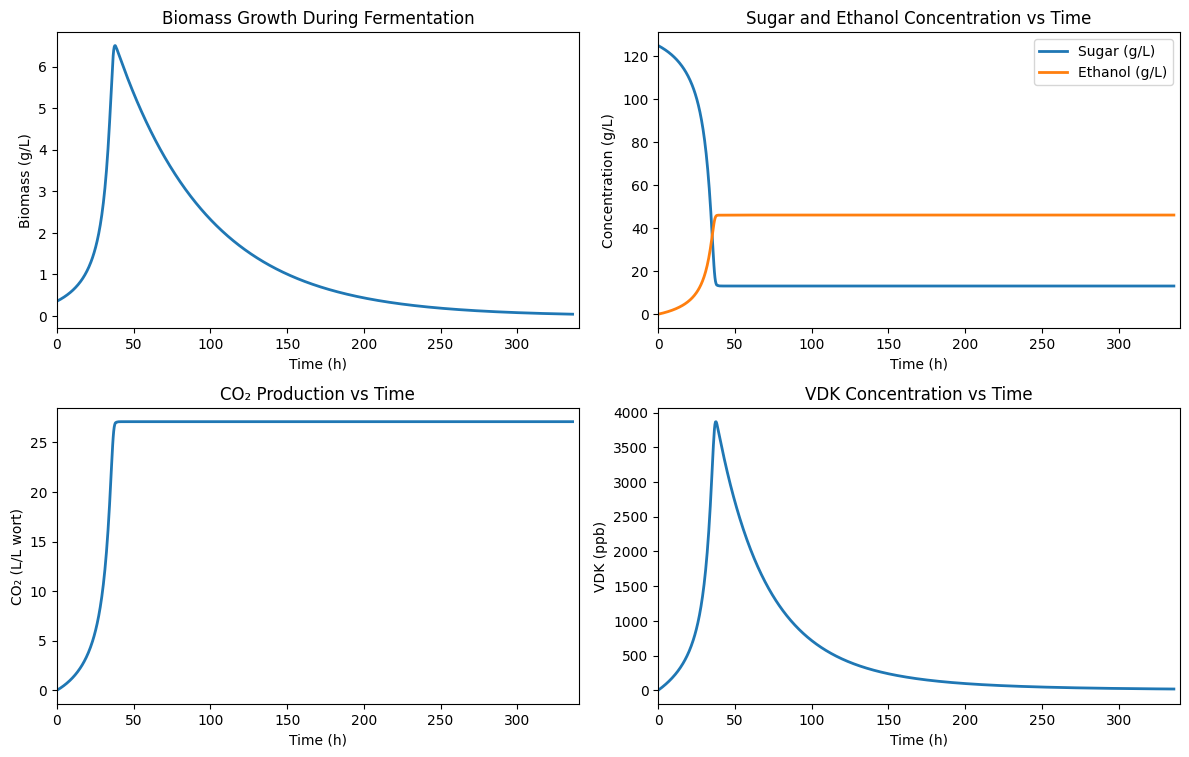

Final VDK:    18.45 ppb
Final ABV:    5.84 %
Final Ethanol:46.08 g/L
Final Sugar:  13.10 g/L
Final CO2:    27.09 L/L
Final Biomass:0.05 g/L


In [0]:
fig, axs = plt.subplots(3, 2, figsize=(12, 11))
axs = axs.flatten()

axs[0].plot(t, x_result, linewidth=2)
axs[0].set_title("Biomass Growth During Fermentation")
axs[0].set_ylabel("Biomass (g/L)")
axs[0].set_xlim(0, 340)

axs[1].plot(t, s_result, linewidth=2, label="Sugar (g/L)")
axs[1].plot(t, e_result, linewidth=2, label="Ethanol (g/L)")
axs[1].set_title("Sugar and Ethanol Concentration vs Time")
axs[1].set_ylabel("Concentration (g/L)")
axs[1].set_xlim(0, 340)
axs[1].legend()

axs[2].plot(t, co2_result, linewidth=2)
axs[2].set_title("CO₂ Production vs Time")
axs[2].set_ylabel("CO₂ (L/L wort)")
axs[2].set_xlim(0, 340)

axs[3].plot(t, ppb_result, linewidth=2)
axs[3].set_title("VDK Concentration vs Time")
axs[3].set_ylabel("VDK (ppb)")
axs[3].set_xlim(0, 340)

fig.delaxes(axs[4])
fig.delaxes(axs[5])

for ax in axs[:4]:
    ax.set_xlabel("Time (h)")
    ax.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Final VDK:    {ppb_result[-1]:.2f} ppb")
print(f"Final ABV:    {abv_result[-1]:.2f} %")
print(f"Final Ethanol:{e_result[-1]:.2f} g/L")
print(f"Final Sugar:  {s_result[-1]:.2f} g/L")
print(f"Final CO2:    {co2_result[-1]:.2f} L/L")
print(f"Final Biomass:{x_result[-1]:.2f} g/L")

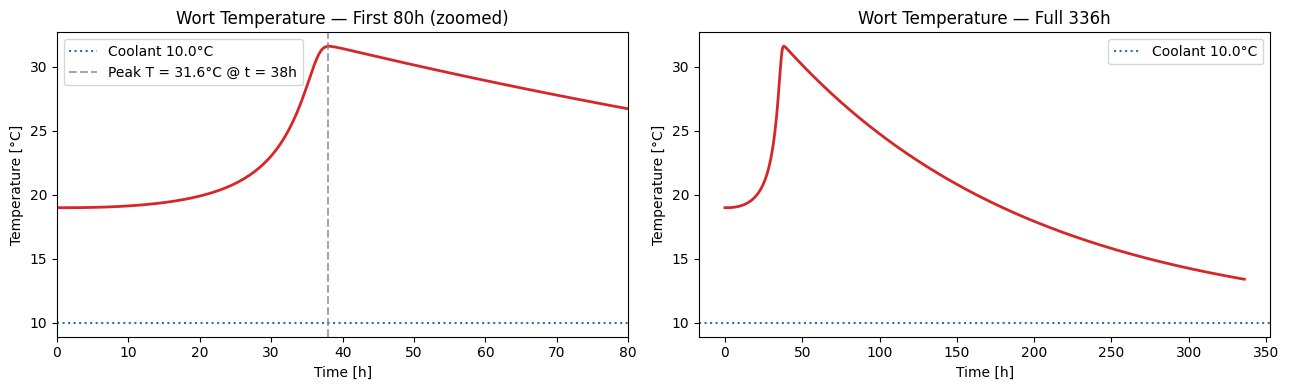

Initial wort temperature: 19.00 °C
Peak wort temperature:    31.62 °C  at t = 38.0 h
Final wort temperature:   13.41 °C

Note: after fermentation sugar hits S_min and Q_gen -> 0.
With no fermentation heat to balance the jacket, the wort cools toward T_c_in.
PID control (to be added) will hold temperature at a setpoint.


In [0]:
# Two-panel temperature plot:
# Left panel zoomed to first 80h (where the temperature rise and peak occur)
# Right panel shows full 336h fermentation
# The rise IS present in the single-panel 336h plot but is visually compressed
# into the first ~40h of a 350h axis, making it appear flat.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: zoomed to first 80h ---
ax1.plot(t, T_result, color='tab:red', linewidth=2)
ax1.axhline(T_c_in, linestyle=':', color='tab:blue', label=f'Coolant {T_c_in}°C')
ax1.axvline(t[T_result.argmax()], linestyle='--', color='grey', alpha=0.7,
            label=f'Peak T = {T_result.max():.1f}°C @ t = {t[T_result.argmax()]:.0f}h')
ax1.set_xlim(0, 80)
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Temperature [°C]')
ax1.set_title('Wort Temperature — First 80h (zoomed)')
ax1.legend()
ax1.grid(False)

# --- Right: full 336h ---
ax2.plot(t, T_result, color='tab:red', linewidth=2)
ax2.axhline(T_c_in, linestyle=':', color='tab:blue', label=f'Coolant {T_c_in}°C')
ax2.set_xlabel('Time [h]')
ax2.set_ylabel('Temperature [°C]')
ax2.set_title('Wort Temperature — Full 336h')
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)

print(f'Initial wort temperature: {T_result[0]:.2f} °C')
print(f'Peak wort temperature:    {T_result.max():.2f} °C  at t = {t[T_result.argmax()]:.1f} h')
print(f'Final wort temperature:   {T_result[-1]:.2f} °C')
print()
print('Note: after fermentation sugar hits S_min and Q_gen -> 0.')
print('With no fermentation heat to balance the jacket, the wort cools toward T_c_in.')
print('PID control (to be added) will hold temperature at a setpoint.')


---
## OPTIONAL: Full Two-ODE Model (Equations 13 & 14 from Rodman et al., 2019)

The paper defines two coupled ODEs for the heat balance:

**Eq. 13 (wort temperature):**
$$\frac{dT}{dt} = \frac{dC_S}{dt} \cdot \Delta H \cdot \frac{1}{\rho_R C_{PR}} + \frac{A_h U}{V_R \rho_R C_{PR}} (T - T_C)$$

**Eq. 14 (jacket temperature):**
$$\frac{dT_C}{dt} = \frac{F}{V_C}(T_{C0} - T_C) + \frac{A_h U}{V_C \rho_C C_{PC}} (T_C - T)$$

Where F is the coolant volumetric flow rate (m³/hr), which acts as the **control variable** in the paper's optimisation.

**Why this is more realistic:** The jacket temperature T_C changes over time — it is not fixed at T_c_in. Fresh coolant enters at T_C0 and the jacket heats up as it absorbs heat from the wort. This lag is especially important at industrial scale (400,000 L vessels).

**Assumption for the cell below:** We use a fixed (constant) coolant flow rate F = 1.0 m³/hr as a demonstration. In the paper, F is optimised over time.

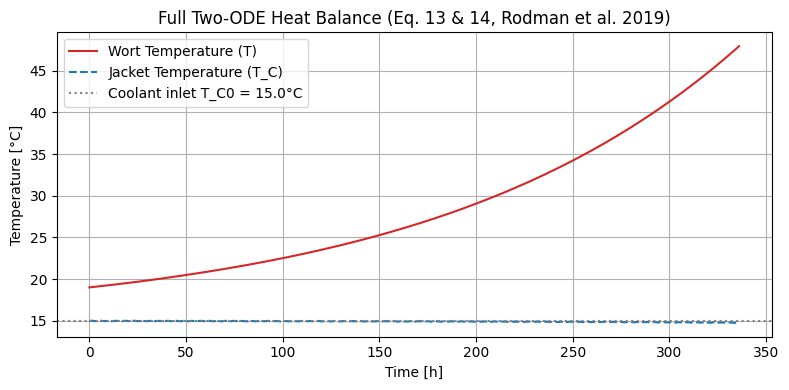

Final wort temperature:   47.96 °C
Final jacket temperature: 14.78 °C


In [0]:
# ===========================================================================
# OPTIONAL: Full two-ODE heat balance (Rodman et al. 2019, Eq. 13 & 14)
# This adds a 7th state variable: T_C (jacket temperature)
# ===========================================================================

# Additional parameters needed for Eq. 14 (all from Table 1, Rodman et al. 2019)
rho_C = 1048.0    # kg/m3, coolant (propylene glycol:water) density
cp_C  = 4180.0   # J/(kg·K), coolant heat capacity
V_C   = 0.01425    # m3, jacket volume (3.8 L scaled to our vessel; paper uses 3.8 m3)
                  # Assumption: jacket volume scaled proportionally with vessel volume
                  # Paper vessel: 400 m3, jacket: 3.8 m3 → ratio 0.0095
                  # Our vessel: 1.5 m3 → jacket ~0.01425 m3,
F_coolant = 1.0 / 3600.0  # m3/s (1 m3/hr, constant flow — in paper this is optimised)
T_C0   = 15.0      # degC, coolant inlet (same as T_c_in above)

def ODE_full(t, state):
    x, s, e, co2, vdk, T, T_C = state

    mu_max_T = a * np.log(T) + b
    r_vdk_T  = c * np.log(T) + d
    mu = max(0, mu_x(s, S_min, mu_max_T))

    # Mass balances (identical to above)
    dx_dt   = (mu * x) - (g_x * x)
    ds_dt   = -k_s * mu * x
    de_dt   =  k_e * mu * x
    dco2_dt =  k_co2 * mu * x
    dvdk_dt =  k_v * mu * x - r_vdk_T * vdk

    # Eq. 13: wort temperature
    # dT/dt = (dCs/dt)*ΔH/(rho_R*Cp_R) + Ah*U*(T-T_C)/(VR*rho_R*Cp_R)
    # Note: ds_dt is in g/(L·h), need to convert to per-second for consistency
    # We work in hours throughout, so dT_dt is in °C/hr
    heat_gen_per_h = (-ds_dt) * dH_ferm    # (g/L/h) * (J/g) = J/(L·h)
    heat_cool_per_h = (A * U * (T - T_C)) / (V_m3 * rho * Cp) * 3600.0  # °C/hr
    dT_dt  = heat_gen_per_h / (rho * Cp) + heat_cool_per_h
    # Simpler form combining terms:
    dT_dt  = ((-ds_dt) * dH_ferm) / (rho * Cp) + (A * U * (T - T_C) * 3600.0) / (V_m3 * rho * Cp)

    # Eq. 14: jacket temperature
    # dT_C/dt = F/V_C*(T_C0 - T_C) + A*U*(T_C - T)/(V_C*rho_C*cp_C)
    # Converting F from m3/s to m3/hr for consistent units
    F_hr = F_coolant * 3600.0   # m3/hr
    dTC_dt = (F_hr / V_C) * (T_C0 - T_C) + (A * U * (T_C - T) * 3600.0) / (V_C * rho_C * cp_C)

    return dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, dT_dt, dTC_dt


# Initial conditions now include T_C0 (jacket starts at coolant inlet temperature)
initial_conditions_full = [x0, s0, e0, co2_0, vdk_0, T0, T_C0]

solution_full = solve_ivp(
    ODE_full,
    t_span=(0, duration),
    y0=initial_conditions_full,
    t_eval=time_points,
    max_step=1.0
)

if solution_full.success:
    T_full   = solution_full.y[5]
    TC_full  = solution_full.y[6]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(solution_full.t, T_full,  label="Wort Temperature (T)", color='tab:red')
    ax.plot(solution_full.t, TC_full, label="Jacket Temperature (T_C)", color='tab:blue', linestyle='--')
    ax.axhline(T_C0, linestyle=':', color='grey', label=f"Coolant inlet T_C0 = {T_C0}°C")
    ax.set_xlabel("Time [h]")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title("Full Two-ODE Heat Balance (Eq. 13 & 14, Rodman et al. 2019)")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    plt.show()
    print(f"Final wort temperature:   {T_full[-1]:.2f} °C")
    print(f"Final jacket temperature: {TC_full[-1]:.2f} °C")
else:
    print("Full ODE solver failed:", solution_full.message)

---
## References

1. **Rodman, A.D., Weaser, M., Griffiths, L., Gerogiorgis, D.I. (2019).** Dynamic Optimisation and Visualisation of Industrial Beer Fermentation with Explicit Heat Transfer Dynamics. *Proceedings of ESCAPE-29*, Eindhoven. Elsevier. — *Primary source for heat balance equations and parameter values.*

2. **de Andrés-Toro, B., Giron-Sierra, J.M., Lopez-Orozco, J.A., et al. (1998).** A kinetic model for beer production under industrial operational conditions. *Math. Comput. Simulat.*, 48(1), 65–74. — *Source of the fermentation kinetic model (Eq. 1–12).*

3. **Boulton, C. and Quain, D. (2008).** *Brewing Yeast and Fermentation.* Wiley. — *Reference for wort physical properties (density, heat capacity).*

4. **Incropera, F.P., DeWitt, D.P., Bergman, T.L., Lavine, A.S. (2006).** *Fundamentals of Heat and Mass Transfer* (6th ed.). Wiley. — *Reference for LMTD method and overall heat transfer coefficient theory.*

5. **Rodman, A.D. and Gerogiorgis, D.I. (2016).** Multi-objective process optimisation of beer fermentation via dynamic simulation. *Food Bioprod. Proc.*, 100(A), 255–274. — *Prior work this paper builds upon.*